In [ ]:
! pip install kagglehub --upgrade

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Country-data.csv"

# Load the latest version
country_data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path
)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.


In [ ]:
country_data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
# drop the country column for clustering

data_for_clustering = country_data.drop(columns=["country"])

# scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

# apply agglomerative clustering
linkage_matrix = linkage(scaled_data, method="ward")

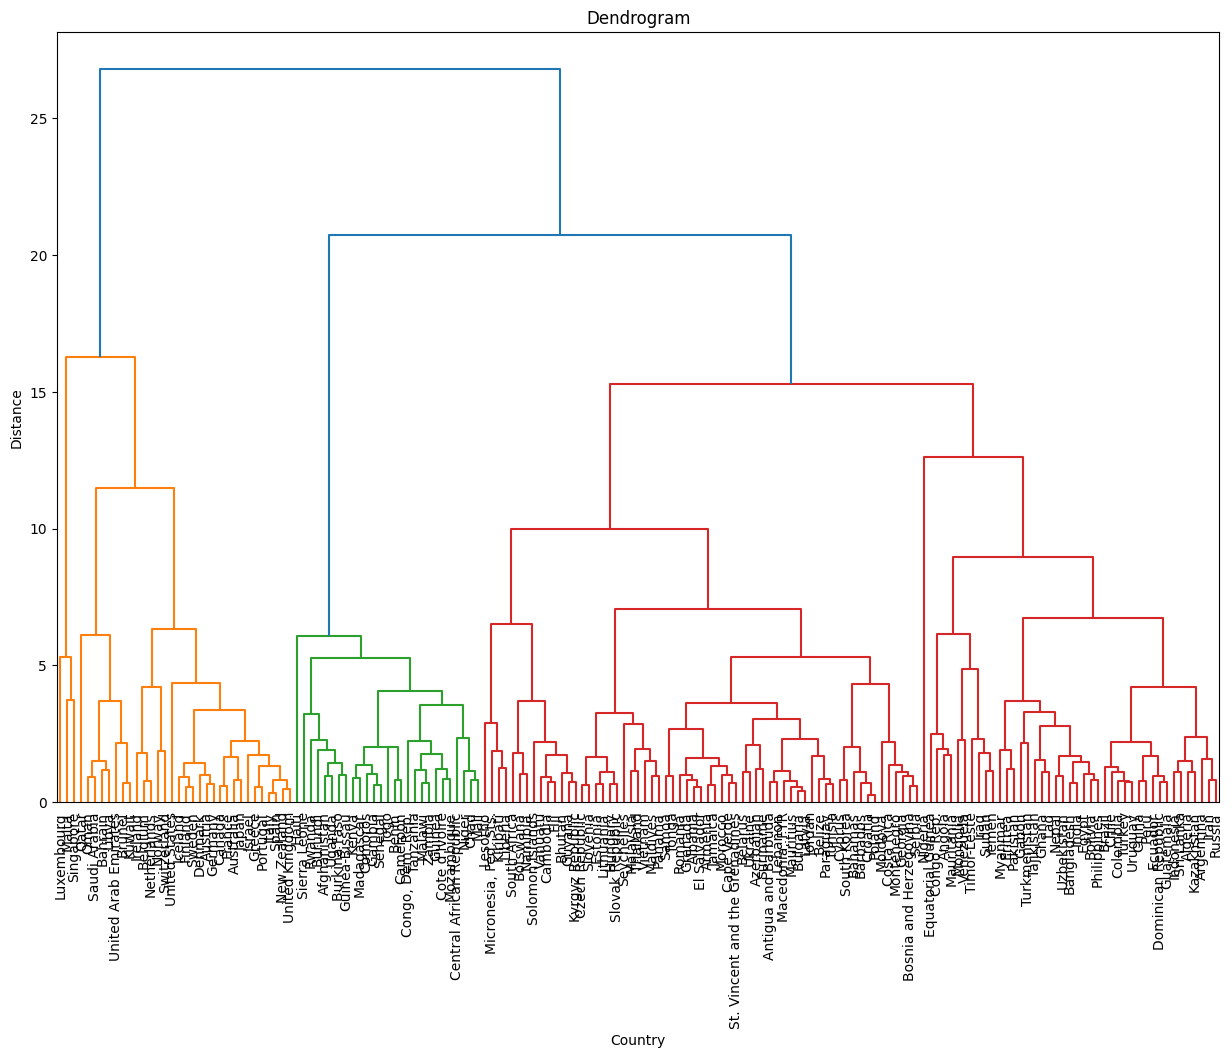

In [ ]:
# plot the dendrogram

plt.figure(figsize=(15, 10))
dendrogram(linkage_matrix,
           labels=country_data["country"].values,
           leaf_font_size=10, leaf_rotation=90)
plt.xlabel("Country")
plt.ylabel("Distance")
plt.title("Dendrogram")
plt.show()

In [ ]:
country_data = country_data.drop(columns=["country"])

In [ ]:
from scipy.cluster.hierarchy import fcluster

# assigning countries to cluster for each level 2
cluster_2 = fcluster(linkage_matrix, 2, criterion="maxclust")

# adding these cluster assignments to data
country_data["cluster_2"] = cluster_2

mean_features_2 = country_data.groupby("cluster_2").mean()

mean_features_2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_2,,,,,,,,,
1,5.961765,58.508824,8.501176,48.902941,47588.235294,4.11550,79.982353,1.888529,43170.588235
2,46.529323,36.660895,6.384812,46.375683,9362.127820,8.71909,68.145865,3.218797,5242.210526


In [ ]:
country_data

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_2
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2


In [ ]:
# assigning countries to cluster for each level 3
cluster_3 = fcluster(linkage_matrix, 3, criterion="maxclust")

# adding these cluster assignments to data
country_data["cluster_3"] = cluster_3

mean_features_3 = country_data.groupby("cluster_3").mean()

mean_features_3

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_2
cluster_3,,,,,,,,,,
1,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235,1.0
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,2.0
3,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,2.0


In [ ]:
country_data.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_2,cluster_3
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,3
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,3
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,3
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,3


In [ ]:
# assigning countries to cluster for each level 4
cluster_4 = fcluster(linkage_matrix, 4, criterion="maxclust")

# adding these cluster assignments to data
country_data["cluster_4"] = cluster_4

mean_features_4 = country_data.groupby("cluster_4").mean()

mean_features_4

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_2,cluster_3
cluster_4,,,,,,,,,,,
1,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667,1.0,1.0
2,6.138710,47.138710,8.666452,38.474194,45996.774194,4.274935,79.841935,1.937742,41777.419355,1.0,1.0
3,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,2.0,2.0
4,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,2.0,3.0
